In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/NLM-ChinaCXRSet-ReadMe.docx
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/NLM-MontgomeryCXRSet-ReadMe.pdf
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/ClinicalReadings/CHNCXR_0499_1.txt
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/ClinicalReadings/CHNCXR_0120_0.txt
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/ClinicalReadings/CHNCXR_0192_0.txt
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/ClinicalReadings/CHNCXR_0548_1.txt
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/ClinicalReadings/CHNCXR_0119_0.txt
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/data/Lung Segmentation/ClinicalReadings/CHNCXR_0403_1.txt
/kaggle/in

In [7]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [8]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [10]:
import os
print(os.listdir("/kaggle/input/datasets"))

['nikhilpandey360']


In [11]:
import os
print(os.listdir("/kaggle/input/datasets/nikhilpandey360"))

['chest-xray-masks-and-labels']


In [13]:
print(os.listdir("/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels"))

['data', 'Lung Segmentation']


In [14]:
import os
print(os.listdir("/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation"))

['NLM-ChinaCXRSet-ReadMe.docx', 'ClinicalReadings', '.ipynb_checkpoints', 'NLM-MontgomeryCXRSet-ReadMe.pdf', 'CXR_png', 'masks', 'test']


In [32]:
image_path = "/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation/CXR_png"

mask_path = "/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation/masks"

In [17]:
import os

print("Images:", len(os.listdir(image_path)))
print("Masks:", len(os.listdir(mask_path)))

Images: 800
Masks: 704


In [25]:
pairs = []

for img in image_files:
    
    mask_name = img.replace(".png", "_mask.png")
    
    if mask_name in mask_files:
        pairs.append((img, mask_name))

print("Valid pairs:", len(pairs))

Valid pairs: 566


In [27]:
print(pairs[0])

('CHNCXR_0092_0.png', 'CHNCXR_0092_0_mask.png')


In [28]:
print(os.path.join(image_path, pairs[0][0]))
print(os.path.join(mask_path, pairs[0][1]))

/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation/images/CHNCXR_0092_0.png
/kaggle/input/datasets/nikhilpandey360/chest-xray-masks-and-labels/Lung Segmentation/masks/CHNCXR_0092_0_mask.png


In [33]:
img = cv2.imread(os.path.join(image_path, pairs[0][0]), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(os.path.join(mask_path, pairs[0][1]), cv2.IMREAD_GRAYSCALE)

print(type(img), img is None)
print(type(mask), mask is None)

<class 'numpy.ndarray'> False
<class 'numpy.ndarray'> False


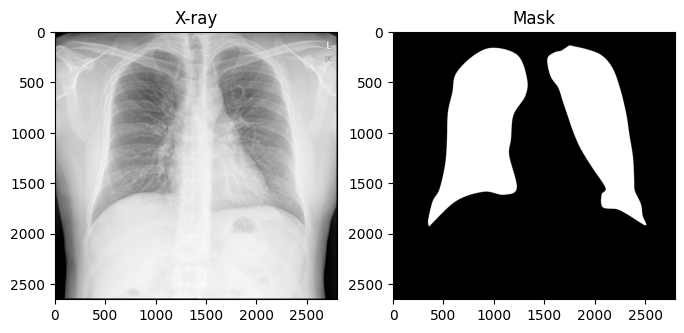

In [34]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("X-ray")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")

plt.show()

In [37]:
IMG_SIZE = 256

In [38]:
X = []
Y = []

for img_name, mask_name in pairs:

    img_path = os.path.join(image_path, img_name)
    mask_path2 = os.path.join(mask_path, mask_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path2, cv2.IMREAD_GRAYSCALE)

    # resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    # normalize image
    img = img / 255.0

    # convert mask to binary
    mask = (mask > 127).astype(np.float32)

    X.append(img)
    Y.append(mask)

In [39]:
X = np.array(X)
Y = np.array(Y)

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)

Images shape: (566, 256, 256)
Masks shape: (566, 256, 256)


In [40]:
X = np.expand_dims(X, axis=-1)
Y = np.expand_dims(Y, axis=-1)

print(X.shape, Y.shape)

(566, 256, 256, 1) (566, 256, 256, 1)


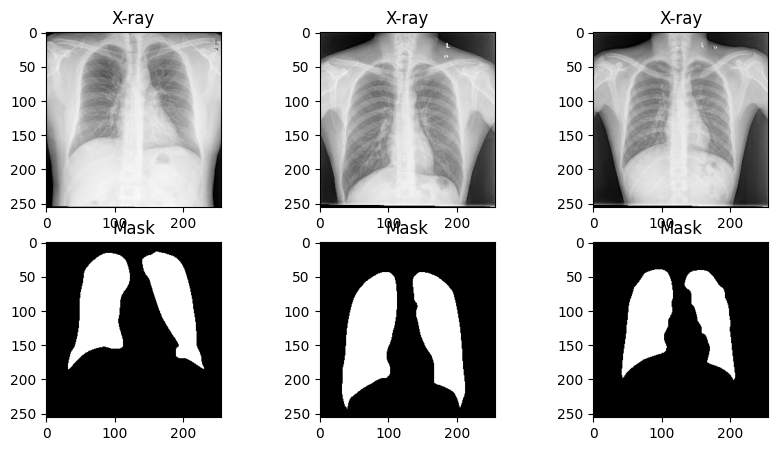

In [41]:
plt.figure(figsize=(10,5))

for i in range(3):

    plt.subplot(2,3,i+1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("X-ray")

    plt.subplot(2,3,i+4)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("Mask")

plt.show()

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (452, 256, 256, 1)
Test: (114, 256, 256, 1)


In [51]:
from tensorflow.keras import layers, models

def build_unet():

    inputs = layers.Input((256,256,1))

    # Encoder
    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(32,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(64,3,activation='relu',padding='same')(p2)
    c3 = layers.Conv2D(64,3,activation='relu',padding='same')(c3)

    # Decoder
    u1 = layers.UpSampling2D()(c3)
    u1 = layers.concatenate([u1,c2])
    c4 = layers.Conv2D(32,3,activation='relu',padding='same')(u1)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2,c1])
    c5 = layers.Conv2D(16,3,activation='relu',padding='same')(u2)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c5)

    model = models.Model(inputs, outputs)

    return model

In [50]:
import tensorflow.keras.backend as K

def dice_coef(y_true, y_pred, smooth=1):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

In [52]:
model = build_unet()

model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=[dice_coef]
)

model.summary()

I0000 00:00:1773388853.880167    1521 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 256, 256,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │         17 │ conv2d_7[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 106,417 (415.69 KB)

 Trainable params: 106,417 (415.69 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
import tensorflow as tf

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

In [64]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=8
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - dice_coef: 0.0602 - loss: 28.0252 - val_dice_coef: 0.1574 - val_loss: 1.7356
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - dice_coef: 0.2490 - loss: 1.6109 - val_dice_coef: 0.3184 - val_loss: 1.3615
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - dice_coef: 0.3018 - loss: 1.3254 - val_dice_coef: 0.3328 - val_loss: 1.2253
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - dice_coef: 0.3385 - loss: 1.2055 - val_dice_coef: 0.3748 - val_loss: 1.1117
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - dice_coef: 0.3863 - loss: 1.0884 - val_dice_coef: 0.4354 - val_loss: 0.9969
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - dice_coef: 0.4526 - loss: 0.9678 - val_dice_coef: 0.4934 - val_loss: 0.8769
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - dice_coef: 0.5155 - loss: 0.8426 - val_dice_coef: 0.5350 - val_loss: 0.7938
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - dice_coef: 0.5793 - loss: 0.7306 - val_dice

In [66]:
pred = model.predict(X_test)

pred_mask = (pred > 0.5).astype("uint8")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step


In [65]:
print(pred.min(), pred.max())

0.0 1.0099057e-08


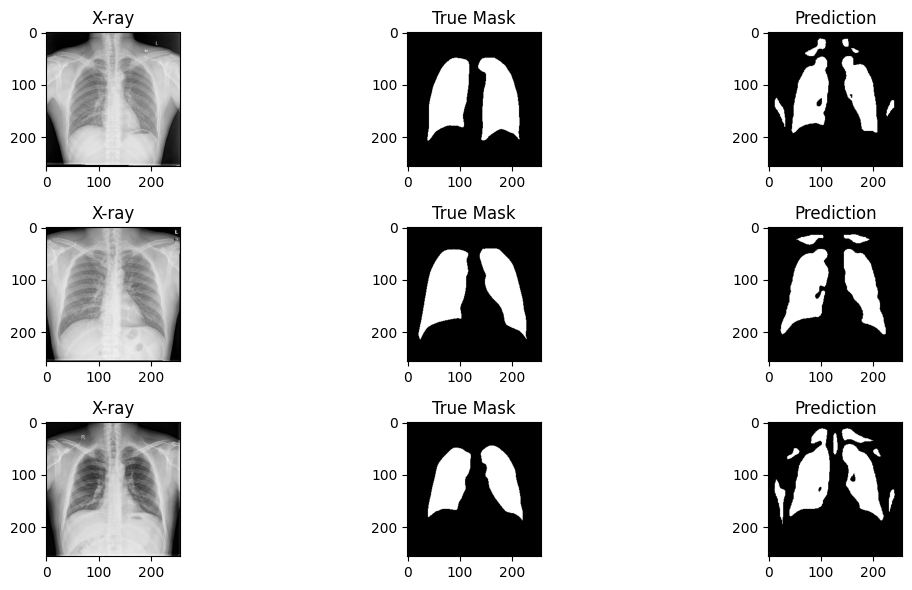

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(3):

    plt.subplot(3,3,i*3+1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title("X-ray")

    plt.subplot(3,3,i*3+2)
    plt.imshow(y_test[i].squeeze(), cmap="gray")
    plt.title("True Mask")

    plt.subplot(3,3,i*3+3)
    plt.imshow(pred_mask[i].squeeze(), cmap="gray")
    plt.title("Prediction")

plt.tight_layout()
plt.show()

In [68]:
results = model.evaluate(X_test, y_test)

print("Loss:", results[0])
print("Dice Score:", results[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - dice_coef: 0.7795 - loss: 0.4640
Loss: 0.45619311928749084
Dice Score: 0.7830718159675598


In [69]:
pred = model.predict(X_test)

pred_mask = (pred > 0.2).astype(np.uint8)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [74]:
def overlay_mask(image, mask):

    image = image.squeeze()

    image_rgb = cv2.cvtColor((image*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)

    red_mask = np.zeros_like(image_rgb)
    red_mask[:,:,0] = mask.squeeze()*255

    overlay = cv2.addWeighted(image_rgb,1,red_mask,0.4,0)

    return overlay

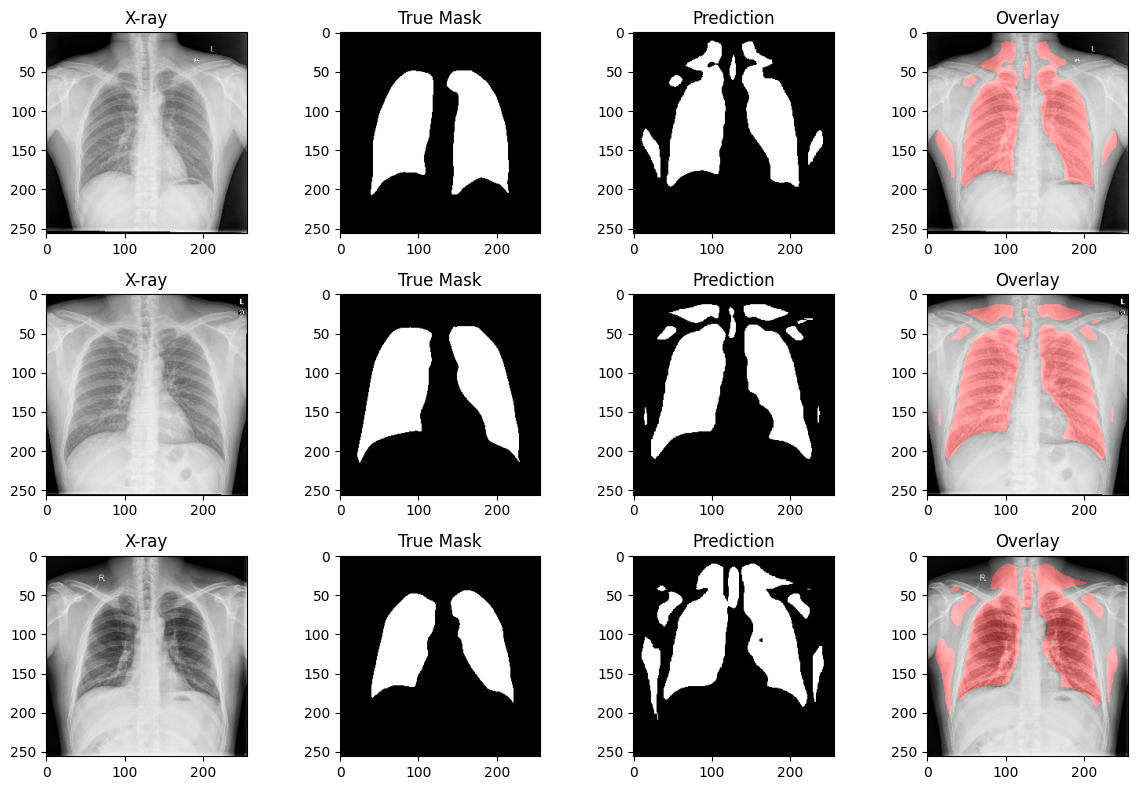

In [75]:
plt.figure(figsize=(12,8))

for i in range(3):

    # X-ray
    plt.subplot(3,4,i*4+1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title("X-ray")

    # True mask
    plt.subplot(3,4,i*4+2)
    plt.imshow(y_test[i].squeeze(), cmap="gray")
    plt.title("True Mask")

    # Prediction
    plt.subplot(3,4,i*4+3)
    plt.imshow(pred_mask[i].squeeze(), cmap="gray")
    plt.title("Prediction")

    # Overlay
    overlay = overlay_mask(X_test[i], pred_mask[i])

    plt.subplot(3,4,i*4+4)
    plt.imshow(overlay)
    plt.title("Overlay")

plt.tight_layout()
plt.show()

In [78]:
for i in range(5):

    overlay = overlay_mask(X_test[i], pred_mask[i])

    cv2.imwrite(f"lung_overlay_{i}.png", overlay)

In [80]:
model.save("lung_segmentation_unet.keras")